# Introduction

This will cover Regularized Logistic Regression (1st method)

Comparison of data with the following paper [[3]](../README.md#ref-3)

## 1 Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import seaborn as sns

## 2 Loading and data visualization

In [2]:
# Load data
df = pd.read_excel("../data/Dry_Bean_Dataset.xlsx")
X = df.drop(columns=["Class"])
y = df["Class"]
y_encoded, y_labels = pd.factorize(df["Class"])
X.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166


In [3]:
y.head()

0    SEKER
1    SEKER
2    SEKER
3    SEKER
4    SEKER
Name: Class, dtype: object

## 2.1 Splitting data set

Split the data in test and training data. It is advices reserving 20 - 40% of data set for testing. In this case, 33% of data is used for testing.

Then split test data in cross-validation and test in half. This way will be able to cross-validate the model and tune it before feeding test data which is done only once. Follow the following division precentage:
 
 * train - 67%
 * cross-validation - 16.5%
 * test - 16.5%

In [4]:
# Split
X_train, X_, y_train, y_ = train_test_split(
    X, y, test_size=0.33, stratify=y, random_state=42
)
X_cv, X_test, y_cv, y_test = train_test_split(
    X_, y_, test_size=0.5, stratify=y_, random_state=42
)
print("X_train.shape", X_train.head, "y_train.shape", y_train.head)
print("X_test.shape", X_test.head, "y_test.shape", y_test.head)
print("X_cv.shape", X_cv.head, "y_cv.shape", y_cv.head)

X_train.shape <bound method NDFrame.head of          Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
6172    51106    887.937       369.488627       176.544117      2.092897   
973     38974    717.630       245.885594       202.118923      1.216539   
1067    39445    725.307       258.509574       194.666850      1.327959   
223     34594    670.069       233.440888       188.865991      1.236013   
11664   31289    647.136       240.135545       166.143113      1.445354   
...       ...        ...              ...              ...           ...   
2172    57563    986.047       343.635912       213.958916      1.606084   
5392    90045   1160.436       441.457341       262.640818      1.680841   
2477    65806   1042.863       361.126192       234.700328      1.538669   
6628    55136    934.076       385.091541       183.023761      2.104052   
3527   163117   1524.028       560.180104       371.857035      1.506439   

       Eccentricity  ConvexArea  EquivDiame

In [5]:
# Check Class Balance
print("\nTraining Class Counts:", X_train.shape)
print(pd.Series(y_train).value_counts(normalize=True))

print("\nCV Class Counts:", X_cv.shape)
print(pd.Series(y_cv).value_counts(normalize=True))

print("\nTest Class Counts: ", X_test.shape)
print(pd.Series(y_test).value_counts(normalize=True))


Training Class Counts: (9119, 16)
Class
DERMASON    0.260555
SIRA        0.193662
SEKER       0.148920
HOROZ       0.141682
CALI        0.119750
BARBUNYA    0.097050
BOMBAY      0.038381
Name: proportion, dtype: float64

CV Class Counts: (2246, 16)
Class
DERMASON    0.260463
SIRA        0.193678
SEKER       0.149154
HOROZ       0.141585
CALI        0.119768
BARBUNYA    0.097061
BOMBAY      0.038290
Name: proportion, dtype: float64

Test Class Counts:  (2246, 16)
Class
DERMASON    0.260463
SIRA        0.193678
SEKER       0.148709
HOROZ       0.141585
CALI        0.119768
BARBUNYA    0.097507
BOMBAY      0.038290
Name: proportion, dtype: float64


## 2.2 Visualization

Visual check of the class distirbution with bar chart

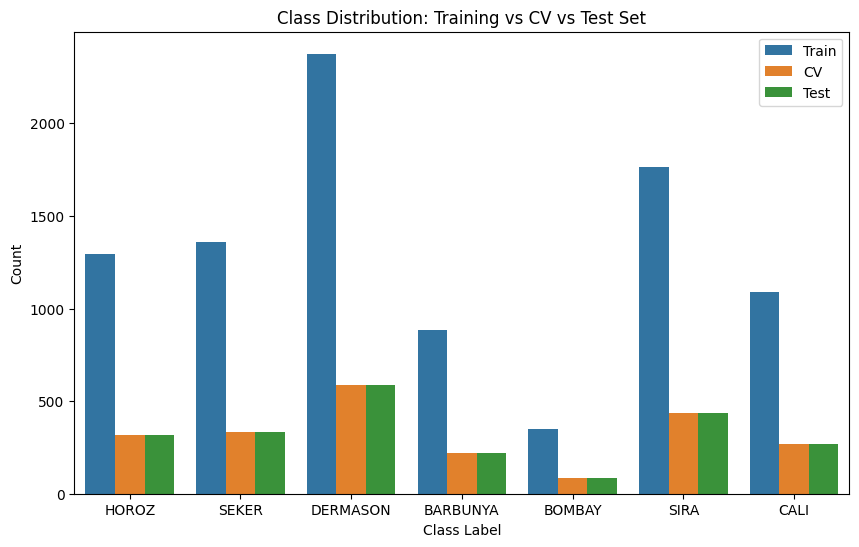

In [6]:
# Convert y_train and y_test to DataFrames for easier plotting with Seaborn
train_df = pd.DataFrame({'Label': y_train, 'Set': 'Train'})
test_cv = pd.DataFrame({'Label': y_cv, 'Set': 'CV'})
test_df = pd.DataFrame({'Label': y_test, 'Set': 'Test'})
combined_df = pd.concat([train_df, test_cv, test_df])

plt.figure(figsize=(10, 6))
sns.countplot(data=combined_df, x='Label', hue='Set')
plt.title('Class Distribution: Training vs CV vs Test Set')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.legend()
plt.show()

Visual check with PCA scatter Plot. All 16 feawtures are squashed in 2 dimensions using PCA (Principal Component Analysis). This lets see if the training and test data occupy the same "space".

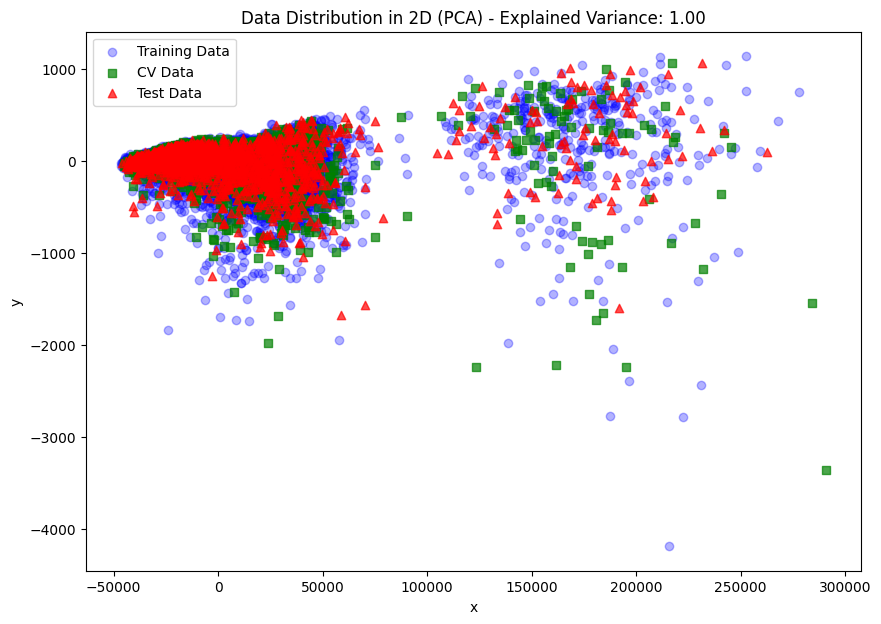

In [7]:
# 1. Compress 16 features down to 2 components
pca = PCA(n_components = 2)
X_train_pca = pca.fit_transform(X_train) # Fit on train
X_cv_pca = pca.transform(X_cv)       # Transform cv using train's rules
X_test_pca = pca.transform(X_test)       # Transform test using train's rules

# 2. Plot
plt.figure(figsize=(10, 7))

# Plot Training data (faded blue)
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
            alpha=0.3, label='Training Data', c='blue')

# Plot CV data (brown)
plt.scatter(X_cv_pca[:, 0], X_cv_pca[:, 1],
            alpha=0.7, label='CV Data', c='green', marker='s')

# Plot Test data (bright red)
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1],
            alpha=0.7, label='Test Data', c='red', marker='^')

plt.title(f'Data Distribution in 2D (PCA) - Explained Variance: {pca.explained_variance_ratio_.sum():.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

## 3 Pipeline for Logistic Regression

### 3.1 No regularization

In [8]:
# Pipeline with scaling + regularized logistic regression
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="saga",
        warm_start=True,
        max_iter=1000,
        multi_class="multinomial"
    ))
])

In [9]:
# Train
model.fit(X_train, y_train)

/mnt/d/Uni/ML/dry-bean-classification/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/mnt/d/Uni/ML/dry-bean-classification/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,steps,"[('scaler', ...), ('logreg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


### 3.1.1 Evaluation

In [10]:
# predict and evaluate on training data
y_train_pred = model.predict(X_train)
acc_train = accuracy_score(y_train, y_train_pred)
error_rate_train = 1 - acc_train

# predict and evaluate on cv data, find error
y_cv_pred = model.predict(X_cv)
acc_cv = accuracy_score(y_cv, y_cv_pred)
error_rate_cv = 1 - acc_cv

# predict and evaluate on test data, find error
y_test_pred = model.predict(X_test)
acc_test = accuracy_score(y_test, y_test_pred)
error_rate_test = 1 - acc_test

# Print Comparison
print(f"Training Accuracy and error rate: {acc_train*100:.2f} {error_rate_train*100:.2f}%")
print(f"CV Accuracy and error rate: , CV Accuracy: {acc_cv*100:.4f} {error_rate_cv*100:.2f}%")
print(f"Test Accuracy and error rate: , Test Accuracy: {acc_test*100:.4f} {error_rate_test*100:.2f}%")

Training Accuracy and error rate: 92.60 7.40%
CV Accuracy and error rate: , CV Accuracy: 92.7872 7.21%
Test Accuracy and error rate: , Test Accuracy: 91.5405 8.46%


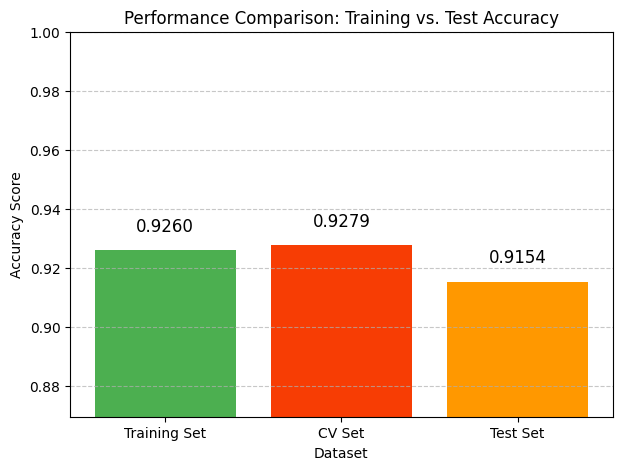

In [11]:
scores = [acc_train, acc_cv, acc_test]
labels = ['Training Set', 'CV Set', 'Test Set']

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, scores, color=['#4CAF50', "#F73D04", '#FF9800']) 
plt.ylim(min(scores) * 0.95, 1.0) 
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}', ha='center', va='bottom', fontsize=12)

plt.title('Performance Comparison: Training vs. Test Accuracy')
plt.ylabel('Accuracy Score')
plt.xlabel('Dataset')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show() # Display the bar chart

Iterative training loop with 1000 iteration step. Extracting accuraccy of training and cv and plotting the differences.

In [12]:
# --- Iterative Training Loop ---
model_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2", 
        solver="saga",
        max_iter=1,
        warm_start=True,
        multi_class="multinomial",
        random_state=42
    ))
])

iterations = []
train_scores = []
cv_scores = []
start_iter = 1000
end_iter = 10000
step_size = 1000

for i in range(start_iter, end_iter + 1, step_size):
    model_pipe.set_params(logreg__max_iter=i)
    model_pipe.fit(X_train, y_train)
    
    iterations.append(i)
    
    # Calculate scores...
    y_train_pred = model_pipe.predict(X_train)
    y_cv_pred = model_pipe.predict(X_cv)
    train_scores.append(accuracy_score(y_train, y_train_pred) * 100)
    cv_scores.append(accuracy_score(y_cv, y_cv_pred) * 100)

/mnt/d/Uni/ML/dry-bean-classification/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/mnt/d/Uni/ML/dry-bean-classification/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/mnt/d/Uni/ML/dry-bean-classification/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/mnt/d/Uni/ML/dry-bean-classification/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated

In [13]:
print(train_scores)
print(cv_scores)

[92.59787257374713, 92.59787257374713, 92.59787257374713, 92.59787257374713, 92.59787257374713, 92.59787257374713, 92.59787257374713, 92.59787257374713, 92.59787257374713, 92.59787257374713]
[92.78717720391808, 92.78717720391808, 92.78717720391808, 92.78717720391808, 92.78717720391808, 92.78717720391808, 92.78717720391808, 92.78717720391808, 92.78717720391808, 92.78717720391808]


<function matplotlib.pyplot.show(close=None, block=None)>

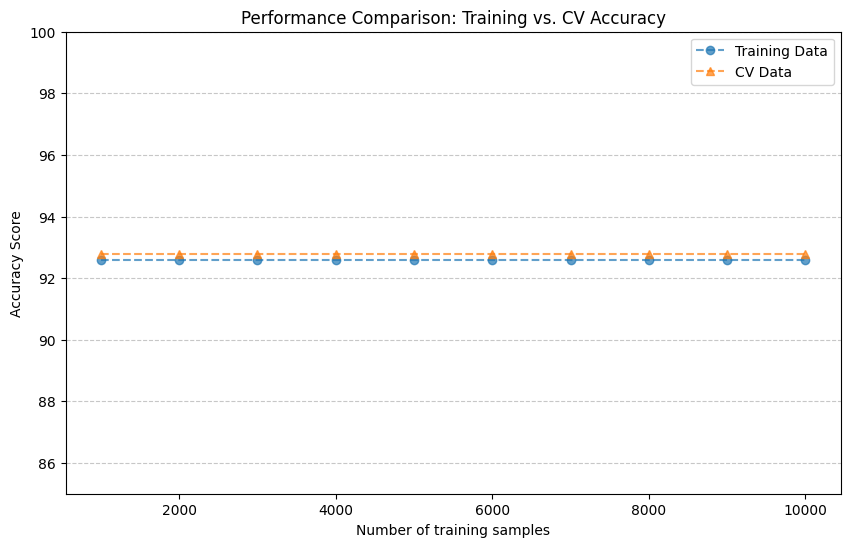

In [14]:
# Plotting code follows...
x = np.array([1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000])
plt.figure(figsize=(10, 6))
plt.plot(x, train_scores, linestyle='dashed', label='Training Data', marker='o', alpha=0.7)
plt.plot(x, cv_scores, linestyle='dashed', label='CV Data', marker='^', alpha=0.7)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Performance Comparison: Training vs. CV Accuracy')
plt.ylabel('Accuracy Score')
plt.xlabel('Number of training samples')
plt.ylim(85, 100)
plt.legend()
plt.show

_Note: Reorder the labels to match the paper comparison [[3]](../README.md#3). The order is `'SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON'`._

**Detailed Report (Precision, Recall, F1-score)**

 * Precision - Out of all the times the model predicted a class, how many were correct?
 * Recal - Out of all the actual instances of a class, how many did the model correctly find?
 * F1-Score - The harmonic mean of Precision and Recall.

In [15]:
print("\n--- Classification Training Report ---")
labels_desired_order = ['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON']
# This provides metrics for each of your 7 classes
print(classification_report(y_train, y_train_pred, labels=labels_desired_order))


--- Classification Training Report ---
              precision    recall  f1-score   support

       SEKER       0.95      0.95      0.95      1358
    BARBUNYA       0.95      0.91      0.93       885
      BOMBAY       1.00      1.00      1.00       350
        CALI       0.93      0.95      0.94      1092
       HOROZ       0.96      0.96      0.96      1292
        SIRA       0.86      0.88      0.87      1766
    DERMASON       0.92      0.92      0.92      2376

    accuracy                           0.93      9119
   macro avg       0.94      0.94      0.94      9119
weighted avg       0.93      0.93      0.93      9119



In [16]:
print("\n--- Classification Test Report ---")
# This provides metrics for each of your 7 classes
print(classification_report(y_test, y_test_pred, labels=labels_desired_order))


--- Classification Test Report ---
              precision    recall  f1-score   support

       SEKER       0.94      0.94      0.94       334
    BARBUNYA       0.96      0.86      0.91       219
      BOMBAY       1.00      1.00      1.00        86
        CALI       0.94      0.94      0.94       269
       HOROZ       0.95      0.96      0.95       318
        SIRA       0.82      0.88      0.85       435
    DERMASON       0.91      0.90      0.91       585

    accuracy                           0.92      2246
   macro avg       0.93      0.93      0.93      2246
weighted avg       0.92      0.92      0.92      2246



***Confusion Matrix (Visualizing where the error occurs)***

In [17]:
cm = confusion_matrix(y_test, y_test_pred, labels=labels_desired_order)
print("\n--- Confusion Matrix (Raw Counts) ---")
print(cm)


--- Confusion Matrix (Raw Counts) ---
[[315   1   0   0   0  11   7]
 [  4 188   0  13   2  12   0]
 [  0   0  86   0   0   0   0]
 [  2   6   0 253   4   4   0]
 [  0   1   0   1 306   5   5]
 [  4   0   0   1  11 382  37]
 [  9   0   0   0   0  50 526]]


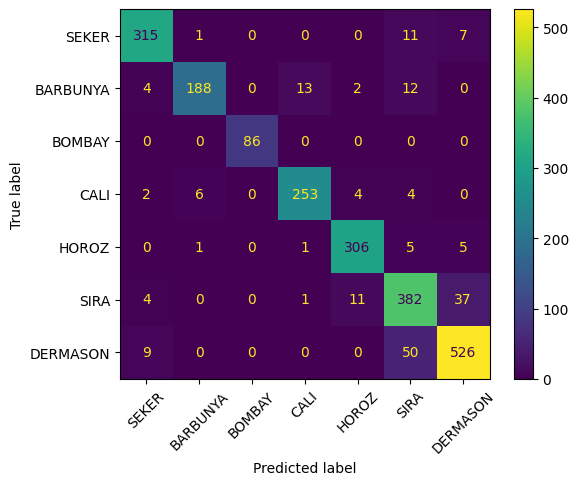

In [18]:
# print(classification_report(y_test, y_pred, labels=[2, 0, 1, 3, 4, 5, 6]))
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, xticks_rotation=45, labels=labels_desired_order)
plt.show()

### 3.2 With regularization

Since the model already achieved a good fit, we can plot a Validation Curve to see how varying the regularization strength (C) affects the model's performance and generalization ability.

In [19]:
# C_values were set from 0.001 (strongest penalty) to 1000.0 (weakest penalty)
C_values = np.logspace(-3, 6, 7) 

train_scores_reg = []
cv_scores_reg = []

for C in C_values:
    model_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            C=C, 
            penalty="l2",
            solver="lbfgs",
            max_iter=5000,
            multi_class="multinomial",
            random_state=42
        ))
    ])
    
    # Train and evaluate the model for the current C
    model_pipe.fit(X_train, y_train)
    # ... record scores ...
    y_train_pred = model_pipe.predict(X_train)
    y_cv_pred = model_pipe.predict(X_cv)
    train_scores_reg.append(accuracy_score(y_train, y_train_pred) * 100)
    cv_scores_reg.append(accuracy_score(y_cv, y_cv_pred) * 100)

/mnt/d/Uni/ML/dry-bean-classification/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/mnt/d/Uni/ML/dry-bean-classification/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/mnt/d/Uni/ML/dry-bean-classification/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/mnt/d/Uni/ML/dry-bean-classification/.venv/li

In [20]:
print(C_values)
print(train_scores_reg)
print(cv_scores_reg)

[1.00000000e-03 3.16227766e-02 1.00000000e+00 3.16227766e+01
 1.00000000e+03 3.16227766e+04 1.00000000e+06]
[89.56025880030705, 92.2469569031692, 92.59787257374713, 92.61980480315825, 92.86105932668056, 92.93782212961948, 92.82816098256387]
[89.53695458593054, 92.47551202137133, 92.78717720391808, 92.56455921638468, 92.60908281389136, 92.60908281389136, 92.52003561887801]


<function matplotlib.pyplot.show(close=None, block=None)>

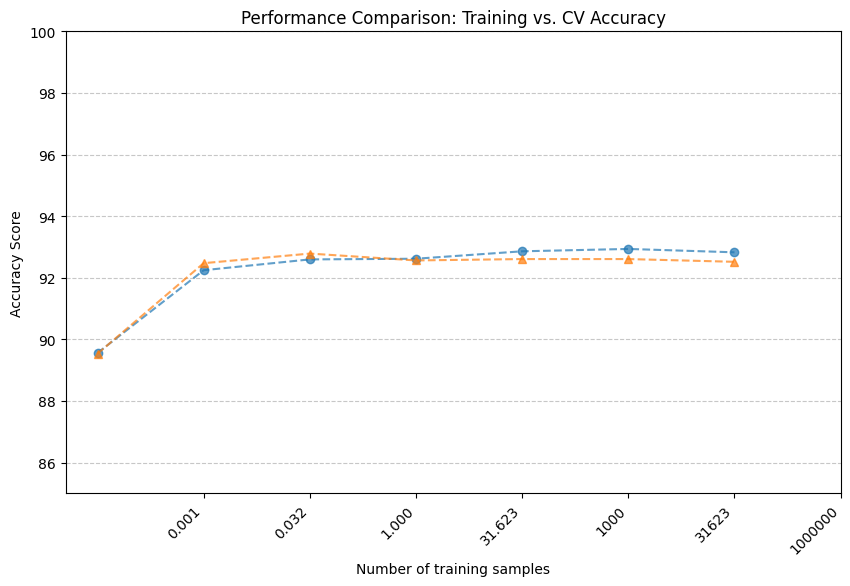

In [21]:
# 1. Transform the numerical array into a list of formatted strings (labels)
labels = [f'{c:.3f}' if c < 100 else f'{c:.0f}' for c in C_values]
val = np.array([1, 2, 3, 4, 5, 6, 7])
# Plotting code follows...
plt.figure(figsize=(10, 6))
plt.plot(train_scores_reg, linestyle='dashed', label='Training Data', marker='o', alpha=0.7)
plt.plot(cv_scores_reg, linestyle='dashed', label='CV Data', marker='^', alpha=0.7)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(val, labels=labels, rotation=45, ha='right')
plt.title('Performance Comparison: Training vs. CV Accuracy')
plt.ylabel('Accuracy Score')
plt.xlabel('Number of training samples')
plt.ylim(85, 100)
plt.show